# Fine-tuning com LoRA: ensinando um modelo de 7 bilhões de parâmetros a responder sobre infecção hospitalar

**Fine-tuning** é continuar o treinamento de um modelo já pronto com dados de um domínio específico, para ele aprender o vocabulário, o estilo e o conteúdo desse domínio. Aqui vamos ajustar o **Llama-2-7b-chat** (7 bilhões de parâmetros) com cerca de 950 pares de pergunta e resposta sobre **epidemiologia hospitalar e controle de infecção**.

Treinar os 7 bilhões de parâmetros exigiria dezenas de GB de memória. Usamos duas técnicas que tornam o treino possível numa única GPU de 16 GB:

- **Quantização em 4 bits** (bitsandbytes): os pesos do modelo base ficam comprimidos e **congelados**;
- **LoRA** (*Low-Rank Adaptation*): em vez de alterar a matriz de pesos $W$, treinamos duas matrizes pequenas $A$ e $B$ e usamos $W + BA$. Só elas são treinadas: **menos de 1% dos parâmetros**.

A combinação das duas se chama **QLoRA**. Roteiro:

1. o que é **LoRA** e o que é **QLoRA**;
2. os **parâmetros do fine-tuning**: o que cada um faz e o que acontece se aumentar ou diminuir;
3. o dataset de perguntas e respostas, com treino, validação e teste;
4. o formato de prompt do Llama-2;
5. o modelo base em 4 bits e as respostas **antes** do treino;
6. os adaptadores LoRA e o treino, com **validação** e **parada antecipada**;
7. as respostas **depois** do treino e uma medida objetiva de melhora.

## 0. Como rodar este notebook

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pasteurjr/notebookvideoaulas/blob/main/08_fine_tuning_lora/notebook/finetuning_lora_infeccao_hospitalar_v3.ipynb)

O curso tem duas partes, com a **mesma estrutura de pastas** (uma pasta por aula):

| O quê | Onde |
|---|---|
| **Código**: os notebooks e os arquivos que eles usam | GitHub: **https://github.com/pasteurjr/notebookvideoaulas** |
| **Dados, vídeos e roteiros** de cada aula | Google Drive: **[pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)** |

**Antes de começar, leia o [README.md da pasta do Google Drive](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)**: ele explica como baixar e organizar os dados de todas as aulas.

**Esta aula (`08_fine_tuning_lora`) usa:** as 958 perguntas e respostas, que **já vêm no GitHub** (`dados/`); o modelo base Llama-2-7b-chat é baixado do Hugging Face (há uma cópia opcional de 13 GB no Drive, junto com o adaptador LoRA treinado na aula); **GPU** (no Colab, a T4 gratuita é suficiente); nenhuma chave de API.

### Opção A: Google Colab (recomendado)

1. **Abra este notebook no Colab** pelo botão **Abrir no Colab** acima (ele abre direto do GitHub).
2. **Ative a GPU gratuita:** **Ambiente de execução → Alterar o tipo de ambiente de execução → GPU T4**.
3. **Rode a célula de preparação logo abaixo.** Ela clona o repositório do GitHub para o Colab e instala só as bibliotecas que faltarem.
4. Depois: **Ambiente de execução → Executar tudo**.

**Se aparecer erro de biblioteca** (`ModuleNotFoundError`, `ImportError` ou erro de versão): crie uma célula nova, rode o comando abaixo, depois vá em **Ambiente de execução → Reiniciar sessão** e rode a célula de preparação de novo.

```
!pip install transformers peft trl bitsandbytes accelerate datasets sentence-transformers
```

### Opção B: no seu computador

Basta baixar. Pré-requisito: [Miniconda](https://docs.conda.io/en/latest/miniconda.html) (ou Anaconda) e Git. No terminal:

```bash
git clone https://github.com/pasteurjr/notebookvideoaulas.git
cd notebookvideoaulas
conda create -n notellm python=3.12 -y
conda activate notellm
pip install torch --index-url https://download.pytorch.org/whl/cu128
pip install transformers peft trl bitsandbytes accelerate datasets sentence-transformers pandas matplotlib jupyter
cd 08_fine_tuning_lora/notebook
jupyter notebook finetuning_lora_infeccao_hospitalar_v3.ipynb
```

**Dados:** já vêm no repositório, na pasta `dados/`.

**Modelo base (opcional):** o notebook baixa o Llama-2-7b-chat do Hugging Face. Para usar a cópia do Drive, baixe `08_fine_tuning_lora/notebook/modelo_base/Llama-2-7b-chat-hf` e coloque o caminho dela em `MODELO_BASE` no arquivo `.env` (no Colab: monte o Drive com `from google.colab import drive; drive.mount("/content/drive")` e defina `os.environ["MODELO_BASE"] = "/content/drive/MyDrive/notebooksvideos/08_fine_tuning_lora/notebook/modelo_base/Llama-2-7b-chat-hf"`).

No computador local, a célula de preparação detecta que não está no Colab e não faz nada.

### Dica: peça ajuda a um assistente de IA

Um assistente de programação, como o **Claude Code** ou o **Codex**, faz toda essa preparação sozinho. Abra o assistente numa pasta vazia e peça, por exemplo:

> Clone https://github.com/pasteurjr/notebookvideoaulas. Crie o ambiente conda `notellm` com Python 3.12 e instale: `pip install torch --index-url https://download.pytorch.org/whl/cu128; pip install transformers peft trl bitsandbytes accelerate datasets sentence-transformers pandas matplotlib jupyter`. Por fim, abra `08_fine_tuning_lora/notebook/finetuning_lora_infeccao_hospitalar_v3.ipynb` no Jupyter.


In [1]:
# PREPARAÇÃO DO AMBIENTE NO GOOGLE COLAB (igual em todos os notebooks do curso; no computador local não faz nada)
AULA = "08_fine_tuning_lora/notebook"                           # pasta desta aula no repositório
USA_DADOS_DO_DRIVE = False                                     # copia os dados da pasta "notebooksvideos" do Drive
PACOTES = {"transformers": "transformers", "peft": "peft", "trl": "trl", "bitsandbytes": "bitsandbytes", "accelerate": "accelerate", "datasets": "datasets", "sentence_transformers": "sentence-transformers"}   # módulo: pacote pip
SECRETS = []                                   # chaves lidas dos Secrets do Colab (ícone 🔑)

import os, sys, shutil, subprocess, importlib.util

if "google.colab" in sys.modules:
    # 1) Código: clona o repositório do GitHub para o Colab
    if not os.path.exists("/content/notebookvideoaulas"):
        subprocess.run(["git", "clone", "-q", "https://github.com/pasteurjr/notebookvideoaulas.git",
                        "/content/notebookvideoaulas"], check=True)
    os.chdir(f"/content/notebookvideoaulas/{AULA}")

    # 2) Dados: copia da pasta "notebooksvideos" (atalho no Meu Drive) para a pasta da aula
    if USA_DADOS_DO_DRIVE and not os.path.exists("dados"):
        from google.colab import drive
        drive.mount("/content/drive")
        origem = f"/content/drive/MyDrive/notebooksvideos/{AULA}/dados"
        if not os.path.exists(origem):
            raise FileNotFoundError(f"Não encontrei {origem}. Coloque a pasta notebooksvideos do curso no seu Meu Drive "
                                    "(veja o README.md da pasta do Google Drive) e rode esta célula de novo.")
        shutil.copytree(origem, "dados")

    # 3) Bibliotecas: instala só as que a sessão do Colab ainda não tem
    faltando = [pip for modulo, pip in PACOTES.items() if importlib.util.find_spec(modulo) is None]
    if faltando:
        print("Instalando:", ", ".join(faltando))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltando], check=True)
        print("Pronto. Se o Colab pedir 'Reiniciar sessão', reinicie e rode esta célula de novo.")
    else:
        print("Todas as bibliotecas já estão instaladas no Colab.")

    # 4) Chaves de API: vêm dos Secrets do Colab (nunca escreva a chave no notebook)
    if SECRETS:
        from google.colab import userdata
        for chave in SECRETS:
            os.environ[chave] = userdata.get(chave)

    print("Pasta da aula:", os.getcwd())
    print("Conteúdo:", sorted(os.listdir(".")))
else:
    print("Ambiente local detectado: usando a pasta atual.")

Ambiente local detectado: usando a pasta atual.


## 1. Bibliotecas e GPU

O modelo base é o **Llama-2-7b-chat**. Usamos a cópia pública do NousResearch no Hugging Face, idêntica à original da Meta e sem precisar pedir acesso. Se você já tem o modelo baixado, coloque o caminho da pasta em `MODELO_BASE` no arquivo `.env`.

In [2]:
import os, json, textwrap, warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"
warnings.filterwarnings("ignore")
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import disable_progress_bars, load_dataset
from dotenv import load_dotenv
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, EarlyStoppingCallback, PrinterCallback
from trl import SFTConfig, SFTTrainer

disable_progress_bars()   # sem barras de progresso nas saídas
load_dotenv()
MODELO_BASE = os.environ.get("MODELO_BASE", "NousResearch/Llama-2-7b-chat-hf")
BF16 = torch.cuda.is_bf16_supported()   # RTX 30xx em diante: bfloat16; T4 do Colab: float16

def mostrar(texto, largura=110):
    print("\n".join(textwrap.fill(p, largura) for p in texto.split("\n")))

print("GPU:", torch.cuda.get_device_name(0), f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB)")
print("Precisão do treino:", "bfloat16" if BF16 else "float16")

GPU: NVIDIA GeForce RTX 5080 (17 GB)
Precisão do treino: bfloat16


## 2. O que é LoRA

Cada camada de um transformer tem matrizes de pesos grandes. No Llama-2-7b, cada projeção de atenção é uma matriz $W$ de **4096 x 4096**: quase **17 milhões de pesos**, e são 7 projeções em cada um dos 32 blocos. O fine-tuning completo atualiza todas elas: $W' = W + \Delta W$.

O **LoRA** (*Low-Rank Adaptation*, Hu e colaboradores, 2021) parte de uma observação: a mudança $\Delta W$ que o fine-tuning precisa fazer tem **posto baixo**, isto é, pode ser escrita como o produto de duas matrizes finas:

$$\Delta W = B \cdot A, \quad B: 4096 \times r, \quad A: r \times 4096$$

- $r$ é o **posto** (*rank*), por exemplo 16: a "largura" do adaptador;
- a matriz original $W$ fica **congelada**; só $A$ e $B$ são treinadas;
- a saída da camada passa a ser $h = W x + \frac{\alpha}{r} B A x$, em que $\alpha$ (`lora_alpha`) é a escala da atualização;
- $B$ começa com zeros: no início do treino, o modelo é **idêntico** ao original;
- no fim, $A$ e $B$ ficam num arquivo pequeno (o **adaptador**), que pode ser aplicado ao modelo base ou fundido nele ($W + BA$).

Matriz W de uma projeção: 4096 x 4096 = 16.777.216 pesos (congelados)

LoRA com r =  8: B (4096 x 8) + A (8 x 4096) =    65.536 pesos treináveis = 0,39% da matriz
LoRA com r = 16: B (4096 x 16) + A (16 x 4096) =   131.072 pesos treináveis = 0,78% da matriz
LoRA com r = 64: B (4096 x 64) + A (64 x 4096) =   524.288 pesos treináveis = 3,12% da matriz


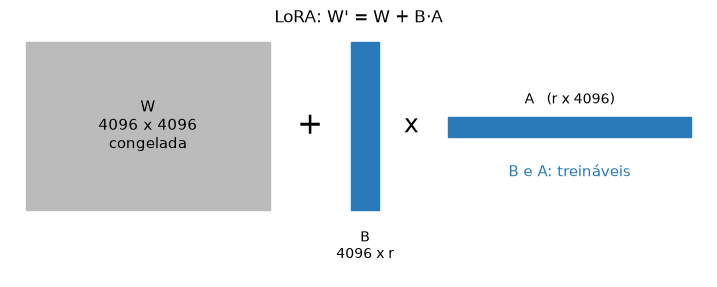

In [3]:
d = 4096                                   # dimensão das projeções de atenção do Llama-2-7b
cheia = d * d
milhar = lambda n: f"{n:_}".replace("_", ".")
print(f"Matriz W de uma projeção: {d} x {d} = {milhar(cheia)} pesos (congelados)\n")
for r in (8, 16, 64):
    treinaveis = d * r + r * d             # B (d x r) + A (r x d)
    pct = f"{100 * treinaveis / cheia:.2f}".replace(".", ",")
    print(f"LoRA com r = {r:>2}: B ({d} x {r}) + A ({r} x {d}) = {milhar(treinaveis):>9} pesos treináveis = {pct}% da matriz")

# desenho: W congelada + B x A treináveis
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.add_patch(plt.Rectangle((0, 0), 3, 3, color="#bbbbbb"));  ax.text(1.5, 1.5, "W\n4096 x 4096\ncongelada", ha="center", va="center", fontsize=11)
ax.text(3.5, 1.5, "+", ha="center", va="center", fontsize=22)
ax.add_patch(plt.Rectangle((4, 0), 0.35, 3, color="#2a7ab9"));  ax.text(4.18, -0.35, "B\n4096 x r", ha="center", va="top", fontsize=10)
ax.text(4.75, 1.5, "x", ha="center", va="center", fontsize=18)
ax.add_patch(plt.Rectangle((5.2, 1.3), 3, 0.35, color="#2a7ab9")); ax.text(6.7, 1.9, "A   (r x 4096)", ha="center", fontsize=10)
ax.text(6.7, 0.6, "B e A: treináveis", ha="center", fontsize=11, color="#2a7ab9")
ax.set_xlim(-0.2, 8.4); ax.set_ylim(-1.2, 3.2); ax.axis("off"); ax.set_title("LoRA: W' = W + B·A")
plt.show()

## 3. O que é QLoRA

Mesmo congelado, o modelo base precisa estar na memória da GPU. Em 16 bits, os 6,7 bilhões de pesos do Llama-2-7b ocupam cerca de **13,5 GB**, e ainda falta espaço para as ativações e o otimizador. O **QLoRA** (Dettmers e colaboradores, 2023) resolve isso **quantizando** o modelo base:

- os pesos congelados são guardados em **4 bits**, no formato **NF4** (*NormalFloat 4*): os 16 valores possíveis seguem a distribuição normal dos pesos de uma rede, o que preserva a precisão;
- a **quantização dupla** comprime também as constantes de escala da quantização;
- na hora de calcular, cada camada é **descomprimida** para 16 bits (`bnb_4bit_compute_dtype`);
- os adaptadores **LoRA** ficam em precisão cheia e são os únicos treinados;
- o **otimizador paginado** move estados para a RAM se a GPU encher.

Resultado: o fine-tuning de um modelo de 7 bilhões de parâmetros cabe numa GPU de 16 GB, e até na T4 gratuita do Colab.

      32 bits:  27,0 GB
      16 bits:  13,5 GB
       8 bits:   6,7 GB
 4 bits (NF4):   3,4 GB


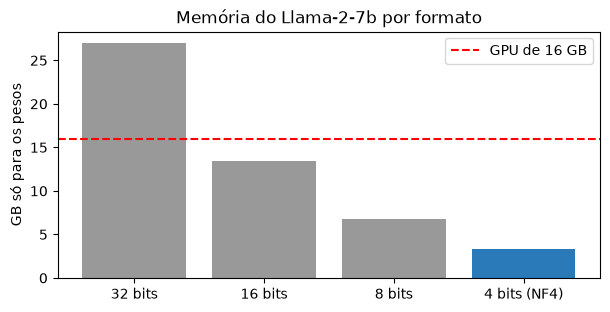

In [4]:
pesos = 6.74e9                             # parâmetros do Llama-2-7b
formatos = {"32 bits": 32, "16 bits": 16, "8 bits": 8, "4 bits (NF4)": 4}
memoria = {nome: pesos * bits / 8 / 1e9 for nome, bits in formatos.items()}
for nome, gb in memoria.items():
    print(f"{nome:>13}: {gb:5.1f} GB".replace(".", ","))

plt.figure(figsize=(7, 3.2))
plt.bar(list(memoria), list(memoria.values()), color=["#999999", "#999999", "#999999", "#2a7ab9"])
plt.axhline(16, color="red", linestyle="--", label="GPU de 16 GB")
plt.ylabel("GB só para os pesos"); plt.title("Memória do Llama-2-7b por formato"); plt.legend()
plt.show()

## 4. Os parâmetros do fine-tuning

A qualidade de um fine-tuning depende muito dos seus **parâmetros ajustáveis**. Eles ficam todos aqui, em quatro grupos, com os **nomes originais** das bibliotecas (`BitsAndBytesConfig`, `LoraConfig`, `SFTConfig`), como num arquivo de parâmetros. Cada um tem um comentário dizendo **o que é**, o que acontece se **aumentar** e se **diminuir**. Para testar outra configuração, basta mudar o valor e rodar o notebook de novo.

### 4.1 Quantização (o "Q" do QLoRA)

In [5]:
load_in_4bit = True
# O que é: carrega os pesos do modelo base comprimidos em 4 bits.
# True: ~3,8 GB de GPU para os 6,7 bilhões de pesos. False: 16 bits (~13,5 GB), mais fiel, mas não cabe para treinar numa GPU de 16 GB.

bnb_4bit_quant_type = "nf4"
# O que é: o formato dos números de 4 bits. "nf4" (NormalFloat 4) distribui os 16 valores como os pesos de uma rede.
# "nf4" perde menos precisão que "fp4"; use "fp4" só para comparar.

bnb_4bit_use_double_quant = True
# O que é: quantiza também as constantes de escala da quantização.
# True: economiza mais ~0,4 GB, com perda desprezível. False: um pouco mais de memória.

bnb_4bit_compute_dtype = torch.bfloat16 if BF16 else torch.float16
# O que é: a precisão dos cálculos; cada camada é descomprimida para ela na hora de calcular.
# bfloat16 (RTX 30xx em diante) é mais estável; float16 é o que a T4 do Colab suporta.

### 4.2 LoRA

In [6]:
lora_r = 16
# O que é: o posto (rank) das matrizes A e B, a "largura" do adaptador.
# Aumentar (32, 64): mais capacidade para padrões complexos; mais memória, adaptador maior e mais risco de overfitting.
# Diminuir (4, 8): adaptador menor e treino mais leve; pode não aprender o suficiente.

lora_alpha = 32
# O que é: a escala da atualização; o efeito real é lora_alpha / lora_r (aqui 32 / 16 = 2).
# Aumentar: o adaptador pesa mais na saída; aprende mais rápido, mas pode ficar instável.
# Diminuir: mudanças mais sutis no modelo. Regra comum: lora_alpha = 2 x lora_r.

lora_dropout = 0.05
# O que é: fração das entradas do adaptador desligada ao acaso em cada passo (regularização).
# Aumentar (0.1 a 0.3): menos overfitting, útil com poucos dados; aprende mais devagar.
# Diminuir (0): aprende mais rápido, mas decora com mais facilidade.

target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
# O que é: em quais camadas de cada bloco entram adaptadores (atenção: q, k, v, o; densas: gate, up, down).
# Mais camadas: mais capacidade e mais pesos treináveis. Menos (só q_proj e v_proj): mais leve, aprende menos.

### 4.3 Treinamento

In [7]:
num_train_epochs = 3
# O que é: quantas vezes o modelo vê o dataset de treino inteiro.
# Aumentar: aprende mais conteúdo, até começar a decorar (a perda de validação sobe); treino mais longo.
# Diminuir: treino mais curto; o modelo pode não aprender o suficiente.

learning_rate = 2e-4
# O que é: o tamanho do passo de cada ajuste dos pesos. É o parâmetro mais importante.
# Aumentar (5e-4, 1e-3): aprende mais rápido, mas a perda oscila, pode divergir e o modelo decora.
# Diminuir (2e-5): treino estável, mas lento; em poucas épocas aprende pouco. Com LoRA, o usual é de 1e-4 a 3e-4.

lr_scheduler_type = "cosine"
# O que é: como a taxa de aprendizado muda durante o treino.
# "cosine": desce suave até perto de zero; "linear": desce em reta; "constant": não muda. Taxa caindo no fim ajuda a estabilizar.

warmup_ratio = 0.03
# O que é: fração inicial do treino em que a taxa sobe de 0 até learning_rate (aquecimento).
# Aumentar: começo mais estável, sem estragar o modelo nos primeiros passos. Diminuir: chega antes à taxa máxima.

weight_decay = 0.001
# O que é: a cada passo, puxa os pesos treinados em direção a zero (regularização).
# Aumentar (0.01, 0.1): menos overfitting, mas pode atrapalhar o aprendizado. Diminuir (0): mais liberdade para os pesos.

max_grad_norm = 0.3
# O que é: gradient clipping, o limite do tamanho do gradiente em cada passo.
# Diminuir: treino mais estável, passos contidos. Aumentar (1.0, o padrão): passos maiores, risco de saltos na perda.

optim = "paged_adamw_8bit"
# O que é: o otimizador. AdamW com estados em 8 bits e paginados (vão para a RAM se a GPU encher).
# "adamw_torch" (32 bits): um pouco mais preciso, mas usa bem mais memória.

per_device_train_batch_size = 8
# O que é: quantos exemplos a GPU processa de uma vez (o lote).
# Aumentar: mais rápido e gradiente mais estável, mas mais memória (pode faltar). Diminuir: cabe em GPUs menores; atualizações mais ruidosas.

gradient_accumulation_steps = 1
# O que é: soma os gradientes de N lotes antes de atualizar os pesos. Lote efetivo = batch x N.
# Aumentar: simula um lote maior sem gastar memória, com menos atualizações por época. Útil na T4 (ex.: batch 4 x 2).

gradient_checkpointing = True
# O que é: não guarda as ativações intermediárias; recalcula na volta (backpropagation).
# True: bem menos memória, treino ~20% mais lento. False: mais rápido, mas pode faltar memória.

max_seq_length = 512
# O que é: número máximo de tokens por exemplo; o que passar é cortado.
# Aumentar: cabe mais contexto, com mais memória e tempo. Diminuir: mais leve, mas corta textos longos.

### 4.4 Validação, parada antecipada e geração

In [8]:
validation_fraction = 0.05
# O que é: parte do treino separada só para medir a perda de validação.
# Aumentar: medida mais confiável, sobra menos para treinar. Diminuir: mais dados de treino, validação mais ruidosa.

eval_steps = 20
# O que é: de quantos em quantos passos a perda de validação é medida (e um checkpoint é salvo).
# Diminuir: acompanha melhor o treino, mas avalia mais vezes (mais lento). Aumentar: mais rápido, parada menos precisa.

early_stopping_patience = 3
# O que é: quantas avaliações seguidas sem melhora são toleradas antes de parar o treino.
# Aumentar: dá mais chance de o modelo voltar a melhorar; treina mais. Diminuir: para mais cedo; pode parar antes da hora.

early_stopping_threshold = 0.01
# O que é: quanto a perda de validação precisa cair para contar como melhora.
# Aumentar: exige melhoras maiores e para mais cedo. Diminuir: qualquer melhora conta.

load_best_model_at_end = True
# O que é: no fim, volta para o checkpoint com a menor perda de validação.
# True: fica com o melhor modelo, e não com o último, que pode ter decorado os exemplos.

max_new_tokens = 150
# O que é: tamanho máximo de cada resposta gerada.
# Aumentar: respostas mais longas, mais tempo. Diminuir: pode cortar a resposta no meio.

repetition_penalty = 1.1
# O que é: penaliza palavras que já saíram na resposta (1.0 = sem penalidade).
# Aumentar (1.3): menos repetição, mas pode evitar termos necessários. Diminuir: mais natural, pode repetir frases.

### 4.5 Resumo: o efeito dos principais parâmetros

| Parâmetro | Para que serve | Se aumentar | Se diminuir |
|---|---|---|---|
| `learning_rate` | tamanho de cada passo de ajuste | aprende rápido, mas oscila e decora | estável, mas lento |
| `num_train_epochs` | quantas vezes o dataset é visto | aprende mais, até decorar | treino curto, pode aprender pouco |
| `lora_r` | capacidade dos adaptadores | mais capacidade e memória, mais overfitting | mais leve, menos capacidade |
| `lora_alpha` | peso da atualização (alpha / r) | mudanças maiores | mudanças mais sutis |
| `lora_dropout` | regularização dos adaptadores | menos overfitting, mais lento | aprende rápido, decora fácil |
| `warmup_ratio` | aquecimento da taxa | começo mais estável | taxa máxima mais cedo |
| `weight_decay` | regularização dos pesos | menos overfitting | mais liberdade |
| `max_grad_norm` | limite do gradiente | passos maiores | mais estável |
| `per_device_train_batch_size` | exemplos por passo | mais rápido, mais memória | cabe em GPU menor |
| `gradient_accumulation_steps` | lote efetivo sem memória extra | lote maior, menos passos | mais atualizações |
| `max_seq_length` | tokens por exemplo | mais contexto e memória | corta textos longos |
| `early_stopping_patience` | tolerância da parada | treina mais | para mais cedo |

A regra de ouro: **mude um parâmetro por vez** e compare a **perda de validação** e a medida de teste do fim do notebook.

## 5. O dataset

Os pares foram gerados a partir dos oito textos da nossa base de conhecimento (a mesma da aula de RAG), pedindo ao DeepSeek perguntas variadas e respostas curtas, no tom de um infectologista explicando a um colega (o script está em `_geracao/gerar_dataset.py`). Dividimos em três partes:

- **treino**: os exemplos que ajustam os pesos;
- **validação** (`validation_fraction`): medida durante o treino, para ver se o modelo está **aprendendo ou decorando**;
- **teste**: 40 pares que o modelo **não** vê em momento nenhum, usados só no fim.

In [9]:
dados = load_dataset("json", data_files="dados/iras_perguntas_respostas.jsonl", split="train")
divisao = dados.train_test_split(test_size=40, seed=42)
treino, teste = divisao["train"], divisao["test"]
divisao = treino.train_test_split(test_size=validation_fraction, seed=42)
treino, validacao = divisao["train"], divisao["test"]
print(f"{len(dados)} pares: {len(treino)} para treino, {len(validacao)} para validação e {len(teste)} para teste\n")

pd.set_option("display.max_colwidth", 70)
treino.to_pandas()[["instruction", "response"]].head(5)

958 pares: 872 para treino, 46 para validação e 40 para teste



,instruction,response
0,Quais casos entram na prevalência?,A prevalência inclui casos novos e antigos. Por isso ela mede a ca...
1,"Se os casos aparecem ligados entre si, isso já caracteriza um surto?","Sim, o aparecimento de casos ligados entre si caracteriza um surto..."
2,O que é vigilância direcionada?,"É priorizar a vigilância em unidades de maior risco, como UTIs, e ..."
3,Infecções por germes multirresistentes são mais fáceis ou mais dif...,São mais difíceis de tratar. Também estão associadas a maior morta...
4,Como aplicar o antibiograma no ajuste do tratamento?,Use o resultado para escolher antibióticos com maior probabilidade...


## 6. O formato de prompt do Llama-2-chat

O Llama-2-chat foi treinado com um formato fixo: uma instrução de sistema entre `<<SYS>>` e a pergunta entre `[INST]` e `[/INST]`. O fine-tuning precisa usar **o mesmo formato**. Cada exemplo vira um **prompt** (a pergunta) e uma **completion** (a resposta). O erro é calculado **só na resposta**: o modelo aprende a responder, não a repetir a pergunta.

In [10]:
SISTEMA = "Você é um assistente de controle de infecção hospitalar. Responda em português, de forma correta e objetiva."

def prompt(pergunta):
    return f"[INST] <<SYS>>\n{SISTEMA}\n<</SYS>>\n\n{pergunta} [/INST]"

def formatar(ex):
    return {"prompt": prompt(ex["instruction"]), "completion": " " + ex["response"]}

treino_fmt = treino.map(formatar, remove_columns=treino.column_names)
validacao_fmt = validacao.map(formatar, remove_columns=validacao.column_names)
exemplo = treino_fmt[0]
print(exemplo["prompt"] + exemplo["completion"])

[INST] <<SYS>>
Você é um assistente de controle de infecção hospitalar. Responda em português, de forma correta e objetiva.
<</SYS>>

Quais casos entram na prevalência? [/INST] A prevalência inclui casos novos e antigos. Por isso ela mede a carga da doença na população naquele momento.


## 7. O modelo base em 4 bits

Com a quantização **NF4** (4 bits, própria para pesos de redes neurais), os 7 bilhões de parâmetros, que ocupariam cerca de 13 GB em 16 bits, cabem em menos de 4 GB.

In [11]:
quantizacao = BitsAndBytesConfig(load_in_4bit=load_in_4bit, bnb_4bit_quant_type=bnb_4bit_quant_type,
                                 bnb_4bit_use_double_quant=bnb_4bit_use_double_quant,
                                 bnb_4bit_compute_dtype=bnb_4bit_compute_dtype)

tokenizer = AutoTokenizer.from_pretrained(MODELO_BASE)
tokenizer.pad_token = tokenizer.unk_token
modelo = AutoModelForCausalLM.from_pretrained(MODELO_BASE, quantization_config=quantizacao, device_map={"": 0})

n = sum(p.numel() * (2 if p.dtype == torch.uint8 else 1) for p in modelo.parameters())   # em 4 bits, 2 pesos por byte
print(f"Parâmetros: {n / 1e9:.2f} bilhões")
print(f"Memória ocupada pelo modelo: {modelo.get_memory_footprint() / 1e9:.1f} GB")

Parâmetros: 6.74 bilhões
Memória ocupada pelo modelo: 3.8 GB


## 8. Antes do fine-tuning

Perguntamos ao modelo original as **perguntas de teste**. Ele é um bom modelo de conversa, mas foi treinado quase só em inglês e não conhece os critérios e definições da nossa base.

In [12]:
@torch.no_grad()
def responder(perguntas, lote=12):
    tokenizer.padding_side = "left"
    respostas = []
    for i in range(0, len(perguntas), lote):
        entrada = tokenizer([prompt(p) for p in perguntas[i:i + lote]], return_tensors="pt", padding=True).to(modelo.device)
        saida = modelo.generate(**entrada, max_new_tokens=max_new_tokens, do_sample=False,
                                repetition_penalty=repetition_penalty,
                                pad_token_id=tokenizer.pad_token_id)
        respostas += tokenizer.batch_decode(saida[:, entrada["input_ids"].shape[1]:], skip_special_tokens=True)
    tokenizer.padding_side = "right"
    return [r.strip() for r in respostas]

perguntas_teste = teste["instruction"]
antes = responder(perguntas_teste)

DEMO = [0, 1, 2]
for i in DEMO:
    print("PERGUNTA:", perguntas_teste[i])
    mostrar("ANTES: " + antes[i])
    print()

PERGUNTA: Prevalência inclui casos antigos?
ANTES: Sim, a prevalência de infecções hospitalares inclui casos antigos. A prevalência é a proporção de
indivíduos que estão infectados com uma determinada infecção em uma população específica, durante um período
determinado.

Em relação às infecções hospitalares, a prevalência pode incluir casos antigos, ou seja, infecções que
ocorreram em tempos passados, mas que ainda estão presentes na população hospitalar. Isso é especialmente
verdadeiro para infecções crônicas, como doenças chronicas inflamatórias, que podem levar a long

PERGUNTA: Qual é o indicador principal de monitoramento de IPCS associada a cateter central?
ANTES: Como um assistente de controle de infecção hospitalar, o indicador principal de monitoramento de IPCS
(Indice de Perfil de Controle de Infecção) associado a cateter central é a incidência de infecções nos
pacientes. O IPCS é uma medida que avalia a exposição dos pacientes a agentes infecciosos, como bactérias ou
vírus, 

## 9. Os adaptadores LoRA

Os adaptadores LoRA usam os parâmetros da seção 4.2: **posto** `lora_r`, escala `lora_alpha` e dropout `lora_dropout`, nas camadas de atenção e nas camadas densas de cada bloco do transformer. O modelo base continua congelado em 4 bits; só os adaptadores são treinados.

In [13]:
lora = LoraConfig(r=lora_r, lora_alpha=lora_alpha, lora_dropout=lora_dropout, bias="none",
                  task_type="CAUSAL_LM", target_modules=target_modules)

modelo = prepare_model_for_kbit_training(modelo)
modelo = get_peft_model(modelo, lora)
modelo.print_trainable_parameters()

trainable params: 39,976,960 || all params: 6,778,392,576 || trainable%: 0.5898


## 10. O treino

Todos os argumentos do treino vêm da célula de parâmetros. A cada `eval_steps` passos, o treino mede a **perda na validação**. Enquanto ela cai, o modelo está aprendendo; quando para de cair e a perda de treino continua caindo, ele começou a **decorar** (overfitting). O **early stopping** para o treino depois de `early_stopping_patience` avaliações sem melhora, e `load_best_model_at_end` volta para o **melhor ponto** da validação. Numa RTX 5080 leva cerca de 6 minutos; na T4 do Colab, cerca de meia hora.

Tempo de treino: 4.7 min | passos: 260 de 327
Melhor perda de validação: 0.797, no passo 220 (early stopping interrompeu o treino)


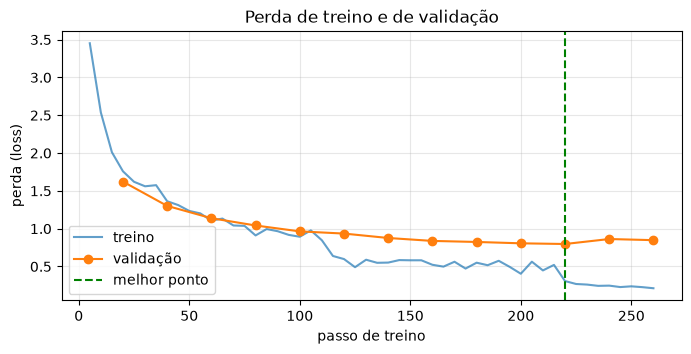

In [14]:
config = SFTConfig(
    output_dir="modelos/checkpoints_v3", report_to="none", disable_tqdm=True, logging_steps=5,
    num_train_epochs=num_train_epochs, learning_rate=learning_rate, lr_scheduler_type=lr_scheduler_type,
    warmup_steps=warmup_ratio,                # número < 1 = fração do treino (nas versões novas, warmup_ratio virou warmup_steps)
    weight_decay=weight_decay, max_grad_norm=max_grad_norm, optim=optim,
    per_device_train_batch_size=per_device_train_batch_size, per_device_eval_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps, gradient_checkpointing=gradient_checkpointing,
    max_length=max_seq_length, bf16=BF16, fp16=not BF16,
    eval_strategy="steps", eval_steps=eval_steps, save_strategy="steps", save_steps=eval_steps,
    save_total_limit=2, load_best_model_at_end=load_best_model_at_end, metric_for_best_model="eval_loss", greater_is_better=False)

parada = EarlyStoppingCallback(early_stopping_patience=early_stopping_patience, early_stopping_threshold=early_stopping_threshold)
trainer = SFTTrainer(model=modelo, args=config, train_dataset=treino_fmt, eval_dataset=validacao_fmt,
                     processing_class=tokenizer, callbacks=[parada])
trainer.remove_callback(PrinterCallback)   # as perdas vão para o gráfico, não para o texto
resultado = trainer.train()

passos_total = trainer.state.max_steps
print(f"Tempo de treino: {resultado.metrics['train_runtime'] / 60:.1f} min | passos: {trainer.state.global_step} de {passos_total}")
print(f"Melhor perda de validação: {trainer.state.best_metric:.3f}, no passo {trainer.state.best_global_step}"
      + (" (early stopping interrompeu o treino)" if trainer.state.global_step < passos_total else ""))

treino_loss = [(r["step"], r["loss"]) for r in trainer.state.log_history if "loss" in r]
valid_loss = [(r["step"], r["eval_loss"]) for r in trainer.state.log_history if "eval_loss" in r]
plt.figure(figsize=(8, 3.5))
plt.plot(*zip(*treino_loss), label="treino", alpha=0.7)
plt.plot(*zip(*valid_loss), marker="o", label="validação")
plt.axvline(trainer.state.best_global_step, color="green", linestyle="--", label="melhor ponto")
plt.xlabel("passo de treino"); plt.ylabel("perda (loss)"); plt.title("Perda de treino e de validação"); plt.grid(alpha=0.3); plt.legend()
plt.show()

## 11. Depois do fine-tuning

As **mesmas perguntas de teste**, que o modelo nunca viu no treino, agora respondidas pelo modelo com os adaptadores LoRA.

In [15]:
modelo.eval()
modelo.config.use_cache = True
depois = responder(perguntas_teste)

for i in DEMO:
    print("PERGUNTA:", perguntas_teste[i])
    mostrar("ANTES: " + antes[i])
    mostrar("DEPOIS: " + depois[i])
    mostrar("REFERÊNCIA: " + teste["response"][i])
    print()

PERGUNTA: Prevalência inclui casos antigos?
ANTES: Sim, a prevalência de infecções hospitalares inclui casos antigos. A prevalência é a proporção de
indivíduos que estão infectados com uma determinada infecção em uma população específica, durante um período
determinado.

Em relação às infecções hospitalares, a prevalência pode incluir casos antigos, ou seja, infecções que
ocorreram em tempos passados, mas que ainda estão presentes na população hospitalar. Isso é especialmente
verdadeiro para infecções crônicas, como doenças chronicas inflamatórias, que podem levar a long
DEPOIS: Não. A prevalência mede a carga atual da doença num momento, incluindo apenas o período de incubação.
REFERÊNCIA: Sim, a prevalência inclui casos novos e antigos. Ela mede a carga da doença num determinado
momento.

PERGUNTA: Qual é o indicador principal de monitoramento de IPCS associada a cateter central?
ANTES: Como um assistente de controle de infecção hospitalar, o indicador principal de monitoramento de I

## 12. Uma medida objetiva

Para não depender só da leitura de alguns exemplos, comparamos **todas** as respostas de teste com as respostas de referência usando **similaridade semântica**: um modelo de embeddings multilíngue transforma cada texto num vetor e medimos o cosseno entre a resposta gerada e a de referência (1 = mesmo significado).

Similaridade média com a referência: antes 0.60  ->  depois 0.73
Perguntas em que o modelo melhorou: 31 de 40


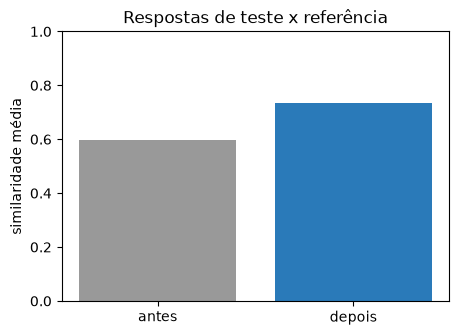

In [16]:
from sentence_transformers import SentenceTransformer, util

avaliador = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
ref = avaliador.encode(teste["response"], convert_to_tensor=True)
sim_antes = util.cos_sim(avaliador.encode(antes, convert_to_tensor=True), ref).diagonal().cpu()
sim_depois = util.cos_sim(avaliador.encode(depois, convert_to_tensor=True), ref).diagonal().cpu()

print(f"Similaridade média com a referência: antes {sim_antes.mean():.2f}  ->  depois {sim_depois.mean():.2f}")
print(f"Perguntas em que o modelo melhorou: {(sim_depois > sim_antes).sum().item()} de {len(teste)}")

plt.figure(figsize=(5, 3.5))
plt.bar(["antes", "depois"], [sim_antes.mean(), sim_depois.mean()], color=["#999999", "#2a7ab9"])
plt.ylim(0, 1); plt.ylabel("similaridade média"); plt.title("Respostas de teste x referência")
plt.show()

## 13. Salvar o adaptador

O que foi aprendido está só nos adaptadores LoRA: um arquivo de algumas dezenas de MB, contra os 13 GB do modelo base. Para usar depois, carrega-se o modelo base e aplica-se o adaptador com `PeftModel.from_pretrained`. Também é possível fundir o adaptador no modelo (`merge_and_unload`) e gerar um modelo único.

In [17]:
modelo.save_pretrained("modelos/adaptador_lora_iras_v3")
tamanho = sum(f.stat().st_size for f in Path("modelos/adaptador_lora_iras_v3").rglob("*") if f.is_file())
print(f"Adaptador salvo em modelos/adaptador_lora_iras_v3: {tamanho / 1e6:.0f} MB")

Adaptador salvo em modelos/adaptador_lora_iras_v3: 160 MB


## 14. Conclusão

- Com **QLoRA**, um modelo de 7 bilhões de parâmetros foi ajustado numa única GPU, treinando menos de 1% dos parâmetros.
- Os **parâmetros** decidem o resultado: taxa de aprendizado, épocas, posto do LoRA e regularização. A **perda de validação** e o **early stopping** mostram quando o modelo para de aprender e começa a decorar.
- Menos de mil exemplos bastaram para o modelo passar a responder **em português**, no **estilo** e com o **conteúdo** do domínio.
- **Fine-tuning ou RAG?** O fine-tuning ensina **estilo, formato e conhecimento estável**; o RAG traz **informação atualizada e com fonte**, sem treinar. Na prática, os dois se combinam: um modelo ajustado ao domínio respondendo a partir dos documentos da instituição.
- Cuidado: um modelo pequeno ajustado ainda pode errar detalhes. Em saúde, as respostas precisam ser revisadas por um especialista.

**Experimente:** mude um parâmetro por vez na seção 4 (por exemplo, `learning_rate = 2e-5` ou `lora_r = 64`), rode de novo e compare a perda de validação e a similaridade. Ou gere mais pares, sobre um protocolo da sua instituição.